In [1]:
import pandas as pd
import numpy as np
import requests, json
import random
from collections import Counter
import networkx as nx
from collections import defaultdict
import matplotlib.pyplot as plt
from pathlib import Path
import re


## Step 1 : Clearly Loading and Cleaning the Ontologies

In [9]:
DATA_DIR        = Path("data")
ISA_DIR         = Path("cleaned_isa");    ISA_DIR.mkdir(exist_ok=True)
OTHER_DIR       = Path("cleaned_other");  OTHER_DIR.mkdir(exist_ok=True)
QUEST_ROOT      = Path("questions")
ISA_QUEST_DIR   = QUEST_ROOT / "isa"
OTHER_QUEST_DIR = QUEST_ROOT / "other"
ISA_QUEST_DIR.mkdir(parents=True, exist_ok=True)
OTHER_QUEST_DIR.mkdir(parents=True, exist_ok=True)

In [26]:
def uri_to_label(uri: str) -> str:
    uri = str(uri).strip("<>")
    label = uri.split("/")[-1].split("#")[-1]
    return label.replace("_", " ").strip()

def write_isa(df: pd.DataFrame, name: str) -> None:
    out = ISA_DIR / f"{name.lower()}.csv"
    df[["Child", "Parent"]].to_csv(out, index=False)
    print(f" is-a  → {out}  ({len(df)})")

def write_other(df: pd.DataFrame, name: str) -> None:
    out = OTHER_DIR / f"{name.lower()}.csv"
    df[["Subject", "Predicate", "Object"]].to_csv(out, index=False)
    print(f"other → {out}  ({len(df)})\n")

In [27]:
def parse_fma_or_rxnorm(csv_path: Path):
    df = pd.read_csv(csv_path)
    id2lab = dict(zip(df["Class ID"], df["Preferred Label"]))

    # is-a
    isa = (
        df[["Preferred Label", "Parents"]]
        .dropna(subset=["Parents"])
        .assign(Parent = lambda d: d["Parents"].map(id2lab))
        .dropna(subset=["Parent"])
        .rename(columns={"Preferred Label": "Child"})
        .loc[:, ["Child", "Parent"]]
    )

    #other relationships
    triples = []
    for pred in df.columns:
        if pred in {"Class ID", "Preferred Label", "Parents"}:
            continue
        for subj, cell in zip(df["Preferred Label"], df[pred]):
            if pd.isna(cell):      # nothing there
                continue
            for obj_id in str(cell).split("|"):
                obj = id2lab.get(obj_id.strip(), obj_id.strip())
                triples.append({"Subject": subj,
                                "Predicate": pred,
                                "Object": obj})
    other = pd.DataFrame(triples)

    return isa, other



def parse_cso(csv_path: Path):
    triples = pd.read_csv(csv_path, header=None, names=["sub", "pred", "obj"])
    isa_rows, other_rows = [], []

    for _, r in triples.iterrows():
        p = str(r["pred"])
        subj = uri_to_label(r["sub"])
        obj  = uri_to_label(r["obj"])

        if "subTopicOf" in p or "superTopicOf" in p:

            if "subTopicOf" in p:
                isa_rows.append({"Child": subj, "Parent": obj})
            else:
                isa_rows.append({"Child": obj,  "Parent": subj})
        else:
            other_rows.append({"Subject": subj,
                               "Predicate": uri_to_label(p),
                               "Object": obj})
    return pd.DataFrame(isa_rows), pd.DataFrame(other_rows)


def parse_pleiades(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path, usecols=["title", "featureTypes"])
    rows = []
    for _, r in df.dropna(subset=["featureTypes"]).iterrows():
        child = str(r["title"]).strip()
        for parent in str(r["featureTypes"]).split(","):
            parent = parent.strip()
            if parent:
                rows.append({"Child": child, "Parent": parent})
    return pd.DataFrame(rows)

In [28]:
def parse_pleiades(csv_path: Path):
    df = pd.read_csv(csv_path)
    isa_rows, other_rows = [], []

    if "featureTypes" in df.columns:
        for _, r in df.dropna(subset=["featureTypes"]).iterrows():
            child = str(r["title"]).strip()
            for parent in str(r["featureTypes"]).split(","):
                parent = parent.strip()
                if parent:
                    isa_rows.append({"Child": child, "Parent": parent})

    return pd.DataFrame(isa_rows), pd.DataFrame(other_rows)

#### Make CSV Files For Relationships
#### One Separate File For is-a Relationships
#### Another One For Other Relationships

In [29]:
ONTOLOGIES = [
    ("FMA",       parse_fma_or_rxnorm, DATA_DIR / "fma.csv"),
    ("RxNorm",    parse_fma_or_rxnorm, DATA_DIR / "RXNORM.csv"),
    ("CSO",       parse_cso,           DATA_DIR / "CSO.3.4.csv"),
    ("Pleiades",  parse_pleiades,      DATA_DIR / "pleiades-places.csv"),
]

for name, parser, path in ONTOLOGIES:
    if not path.exists():
        continue
    isa_df, other_df = parser(path)
    write_isa(isa_df, name)
    if len(other_df):
        write_other(other_df, name)
    else:
        print(f"{name}: no extra predicates found.\n")

C:\Users\elden lord\AppData\Local\Temp\ipykernel_15620\4277518389.py:2: DtypeWarning: Columns (41,71,75,77,99,100,103,113,114,140,156,157,158,178,198) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


 is-a  → cleaned_isa\fma.csv  (104714)
other → cleaned_other\fma.csv  (553098)



C:\Users\elden lord\AppData\Local\Temp\ipykernel_15620\4277518389.py:2: DtypeWarning: Columns (14,24,36,37,38) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


 is-a  → cleaned_isa\rxnorm.csv  (125)
other → cleaned_other\rxnorm.csv  (2251386)

 is-a  → cleaned_isa\cso.csv  (44205)
other → cleaned_other\cso.csv  (121723)

 is-a  → cleaned_isa\pleiades.csv  (51059)
Pleiades: no extra predicates found.



##  Method 1 - Generate Direct Relation Questions
#### First Generate is-a Yes-No Questions With The Answers Are Known

In [114]:
def load_is_a_frames(dir_path: Path = ISA_DIR) -> pd.DataFrame:
    frames = []
    for csv in dir_path.glob("*.csv"):
        frames.append(pd.read_csv(csv))

    all_pairs = pd.concat(frames, ignore_index=True).drop_duplicates()
    return all_pairs

def _read_all_csv(folder: Path, cols: list[str]) -> dict[str, pd.DataFrame]:
    frames = {}
    for csv in folder.glob("*.csv"):
        df = pd.read_csv(csv, usecols=cols)
        frames[csv.stem] = df.drop_duplicates()
    if not frames:
        raise FileNotFoundError(f"No CSVs found in {folder.resolve()}")
    return frames

def _predicate_to_phrase(pred: str) -> str:
    pred = re.sub(r"[_\-]+", " ", pred)
    pred = re.sub(r"([a-z])([A-Z])", r"\1 \2", pred)
    return pred.strip()


def _make_yes_no_isa(df: pd.DataFrame, n_yes: int, n_no: int, rng) -> list[dict]:
    yes_rows = df.sample(n=min(n_yes, len(df)),
                         random_state=rng.randint(0, 2**32 - 1))
    yes_qs = [{"question": f"Is '{r.Child}' a type of '{r.Parent}'?", "answer": "Yes"}
              for _, r in yes_rows.iterrows()]

    child2parents = df.groupby("Child")["Parent"].apply(set).to_dict()
    all_parents   = sorted(set(df["Parent"]))

    no_qs = []
    while len(no_qs) < n_no and len(no_qs) < n_yes * 10:
        child, true_parents = rng.choice(list(child2parents.items()))
        wrong_parent = rng.choice(all_parents)
        if wrong_parent in true_parents:
            continue
        q = f"Is '{child}' a type of '{wrong_parent}'?"
        if q not in {d["question"] for d in no_qs}:
            no_qs.append({"question": q, "answer": "No"})
    return yes_qs + no_qs


def _make_yes_no_other(df: pd.DataFrame, n_yes: int, n_no: int, rng) -> list[dict]:

    # --- clean & normalise
    df = (
        df.dropna(subset=["Subject", "Predicate", "Object"])
          .assign(Subject   = lambda d: d["Subject"].astype(str).str.strip(),
                  Predicate = lambda d: d["Predicate"].astype(str).str.strip(),
                  Object    = lambda d: d["Object"].astype(str).str.strip())
          .query("Subject != '' and Predicate != '' and Object != ''")
    )

    # ---------------- YES
    yes_rows = df.sample(n=min(n_yes, len(df)),
                         random_state=rng.randint(0, 2**32 - 1))
    yes_qs = [
        {"question": f"Is '{r.Subject}' {_predicate_to_phrase(r.Predicate)} '{r.Object}'?",
         "answer": "Yes"}
        for _, r in yes_rows.iterrows()
    ]

    # ---------------- NO
    by_pred_subj = (
        df.groupby(["Predicate", "Subject"])["Object"]
          .apply(set)
          .to_dict()
    )
    all_objects = sorted({obj for obj in df["Object"]})

    no_qs = []
    while len(no_qs) < n_no and len(no_qs) < n_yes * 10:
        (pred_key, subj), obj_set = rng.choice(list(by_pred_subj.items()))
        wrong_obj = rng.choice(all_objects)
        if wrong_obj in obj_set:
            continue
        pred_phrase = _predicate_to_phrase(pred_key)
        q = f"Is '{subj}' {pred_phrase} '{wrong_obj}'?"
        if q not in {d["question"] for d in no_qs}:
            no_qs.append({"question": q, "answer": "No"})

    return yes_qs + no_qs



def _attach_ids(q_items: list[dict], stem: str) -> list[dict]:
    """Add id field '<stem>_qN' to each question dict."""
    for i, itm in enumerate(q_items, 1):
        itm["id"] = f"{stem}_q{i}"
    return q_items


def build_and_save_questions(n_yes: int = 100,
                             n_no:  int = 100,
                             seed:  int | None = None):

    rng       = random.Random(seed)
    combined  = []

    isa_frames = _read_all_csv(ISA_DIR, ["Child", "Parent"])
    for stem, df in isa_frames.items():
        qs = _make_yes_no_isa(df, n_yes, n_no, rng)
        qs = _attach_ids(qs, stem)

        out_csv = ISA_QUEST_DIR / f"{stem}_questions.csv"
        (pd.DataFrame(qs)
           .loc[:, ["id", "question", "answer"]]
           .to_csv(out_csv, index=False))

        print(f"✔︎ ISA   {stem:<12} → {out_csv.name}  ({len(qs)})")
        combined.extend(qs)

    other_frames = _read_all_csv(OTHER_DIR, ["Subject", "Predicate", "Object"])
    for stem, df in other_frames.items():
        qs = _make_yes_no_other(df, n_yes, n_no, rng)
        qs = _attach_ids(qs, stem)

        out_csv = OTHER_QUEST_DIR / f"{stem}_questions.csv"
        (pd.DataFrame(qs)
           .loc[:, ["id", "question", "answer"]]
           .to_csv(out_csv, index=False))

        print(f"✔︎ OTHER {stem:<12} → {out_csv.name}  ({len(qs)})")
        combined.extend(qs)

    rng.shuffle(combined)
    return combined

In [115]:
qlist = build_and_save_questions(n_yes=50, n_no=50, seed=42)
print("\nSample questions:")
for q in qlist[:6]:
    print(" ", q)

✔︎ ISA   cso          → cso_questions.csv  (100)
✔︎ ISA   fma          → fma_questions.csv  (100)
✔︎ ISA   pleiades     → pleiades_questions.csv  (100)
✔︎ ISA   rxnorm       → rxnorm_questions.csv  (100)
✔︎ OTHER cso          → cso_questions.csv  (100)
✔︎ OTHER fma          → fma_questions.csv  (100)
✔︎ OTHER rxnorm       → rxnorm_questions.csv  (100)

Sample questions:
  {'question': "Is 'sea state' a type of 'nonlinear optical properties'?", 'answer': 'No', 'id': 'cso_q67'}
  {'question': "Is 'Skin of medial part of middle finger' Obsolete 'False'?", 'answer': 'Yes', 'id': 'fma_q10'}
  {'question': "Is 'Basal ramus of right anterior basal segmental bronchus' a type of 'Basal ramus of anterior basal segmental bronchus'?", 'answer': 'Yes', 'id': 'fma_q41'}
  {'question': "Is 'Temporal Concept' a type of 'Fully Formed Anatomical Structure'?", 'answer': 'No', 'id': 'rxnorm_q68'}
  {'question': "Is 'Second Temple, Jerusalem' a type of 'mountain'?", 'answer': 'No', 'id': 'pleiades_q72'}
  

##  Method 2 - Generate Long Chain Questions

In [85]:
LONG_QUEST_DIR = Path("questions") / "isa_long"
LONG_QUEST_DIR.mkdir(parents=True, exist_ok=True)

In [112]:
def _load_full_isa_graph() -> nx.DiGraph:
    G           = nx.DiGraph()
    node_to_ont = {}
    for csv in ISA_DIR.glob("*.csv"):
        ont = csv.stem.lower()
        df  = pd.read_csv(csv, usecols=["Child", "Parent"])
        G.add_edges_from(zip(df["Child"], df["Parent"]))
        for n in pd.concat([df["Child"], df["Parent"]]).unique():
            node_to_ont[n] = ont
    return G, node_to_ont


def _pick_positive_pairs(G: nx.DiGraph,
                         n_pairs: int,
                         min_len: int,
                         max_len: int,
                         rng: random.Random):
    positives = []
    nodes = list(G.nodes())
    attempts = 0
    while len(positives) < n_pairs and attempts < n_pairs * 30:
        child = rng.choice(nodes)
        dist_map = nx.single_source_shortest_path_length(G, child)
        dist_map = {a: d for a, d in dist_map.items() if d}
        ok_dists = [d for d in dist_map.values() if min_len <= d <= max_len]
        if not ok_dists:
            attempts += 1
            continue

        # pick a random distance first, then a random ancestor at that distance
        target_dist = rng.choice(ok_dists)
        anc_candidates = [a for a, d in dist_map.items() if d == target_dist]
        anc_node = rng.choice(anc_candidates)

        positives.append((child, anc_node))
        attempts += 1
    return positives


def _pick_negative_pairs(G: nx.DiGraph,
                         n_pairs: int,
                         rng: random.Random):
    negatives = []
    nodes = list(G.nodes())
    attempts = 0
    while len(negatives) < n_pairs and attempts < n_pairs * 20:
        child, candidate = rng.sample(nodes, 2)
        if not nx.has_path(G, child, candidate):
            negatives.append((child, candidate))
        attempts += 1
    return negatives


def build_and_save_longchain_questions(n_yes: int = 500,
                                       n_no:  int = 500,
                                       min_len: int = 3,
                                       max_len: int = 10,
                                       seed: int | None = None,
                                       out_name: str = "long_chain_questions"
                                      ) -> list[dict]:


    rng          = random.Random(seed)
    G, node2ont  = _load_full_isa_graph()

    nodes_by_ont = defaultdict(list)
    for node, ont in node2ont.items():
        nodes_by_ont[ont].append(node)

    ont_list = sorted(nodes_by_ont)
    k        = len(ont_list)

    base_yes, extra_yes = divmod(n_yes, k)
    base_no,  extra_no  = divmod(n_no,  k)
    yes_quota = {ont: base_yes + (i < extra_yes) for i, ont in enumerate(ont_list)}
    no_quota  = {ont: base_no  + (i < extra_no)  for i, ont in enumerate(ont_list)}

    LONG_QUEST_DIR.mkdir(parents=True, exist_ok=True)

    combined = []

    for ont in ont_list:
        sub_nodes = nodes_by_ont[ont]
        subG      = G.subgraph(sub_nodes).copy()

        pos_pairs = _pick_positive_pairs(subG, yes_quota[ont],
                                         min_len, max_len, rng)
        if len(pos_pairs) < yes_quota[ont]:
            print(f"⚠️  {ont}: only {len(pos_pairs)}/{yes_quota[ont]} YES pairs found")

        neg_pairs = _pick_negative_pairs(subG, no_quota[ont], rng)
        if len(neg_pairs) < no_quota[ont]:
            print(f"⚠️  {ont}: only {len(neg_pairs)}/{no_quota[ont]} NO pairs found")

        q_items = []
        counter = 1
        for c, a in pos_pairs:
            q_items.append({"id": f"{ont}_q{counter}",
                            "question": f"Is '{c}' a type of '{a}'?",
                            "answer": "Yes"})
            counter += 1

        for c, p in neg_pairs:
            q_items.append({"id": f"{ont}_q{counter}",
                            "question": f"Is '{c}' a type of '{p}'?",
                            "answer": "No"})
            counter += 1

        if q_items:
            out_csv = LONG_QUEST_DIR / f"{ont}_long_questions.csv"
            (pd.DataFrame(q_items)
               .loc[:, ["id", "question", "answer"]]   # id first
               .to_csv(out_csv, index=False))
            print(f"✔︎ {ont:<8} → {out_csv.name}  ({len(q_items)} rows)")

        combined.extend(q_items)

    rng.shuffle(combined)
    out_json = LONG_QUEST_DIR / f"{out_name}.json"
    out_json.write_text(json.dumps(combined, indent=2, ensure_ascii=False),
                        encoding="utf-8")

    print(f"\n total {len(combined)} long-chain Qs → {out_json}")
    return combined

In [113]:
q_long = build_and_save_longchain_questions(
        n_yes=200, n_no=200, min_len=4, max_len=7, seed=123
    )
print("sample:", q_long[:3])

✔︎ cso      → cso_long_questions.csv  (100 rows)
✔︎ fma      → fma_long_questions.csv  (100 rows)
⚠️  pleiades: only 0/50 YES pairs found
✔︎ pleiades → pleiades_long_questions.csv  (50 rows)
✔︎ rxnorm   → rxnorm_long_questions.csv  (100 rows)

 total 350 long-chain Qs → questions\isa_long\long_chain_questions.json
sample: [{'id': 'rxnorm_q57', 'question': "Is 'Classification' a type of 'Bacterium'?", 'answer': 'No'}, {'id': 'cso_q21', 'question': "Is 'triphones' a type of 'database systems'?", 'answer': 'Yes'}, {'id': 'fma_q92', 'question': "Is 'Inferior angle of right scapula' a type of 'Lobule of sebaceous gland'?", 'answer': 'No'}]


### See Details of Questions

YES-question count by path length (per ontology):

[CSO]
  Length 4: 30
  Length 5: 15
  Length 6: 4
  Length 7: 1

[FMA]
  Length 4: 15
  Length 5: 10
  Length 6: 15
  Length 7: 10

[RXNORM]
  Length 4: 25
  Length 5: 18
  Length 6: 7

NO-question count per ontology:
  CSO     : 50
  FMA     : 50
  PLEIADES: 50
  RXNORM  : 50


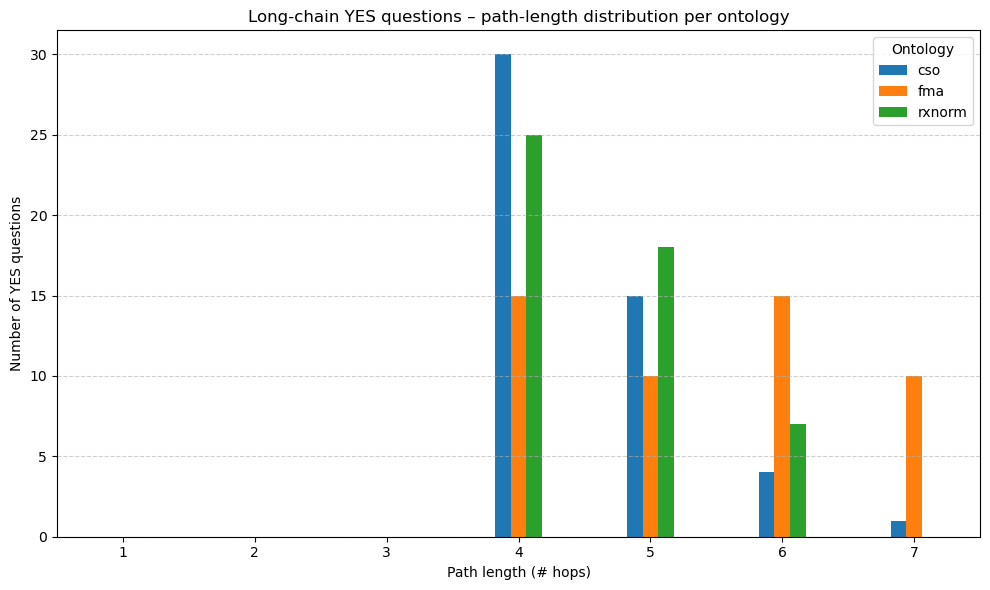

In [116]:
ISA_DIR        = Path("cleaned_isa")
LONG_Q_PATH    = Path("questions/isa_long/long_chain_questions.json")


G_isa = nx.DiGraph()
for csv in ISA_DIR.glob("*.csv"):
    df = pd.read_csv(csv, usecols=["Child", "Parent"])
    G_isa.add_edges_from(zip(df["Child"], df["Parent"]))


with open(LONG_Q_PATH, "r", encoding="utf-8") as fh:
    qa_list = json.load(fh)

pat = re.compile(r"Is '(.+?)' a type of '(.+?)'\?")

yes_pairs, no_pairs = [], []
for item in qa_list:
    m = pat.match(item["question"])
    if not m:
        continue
    pair = m.groups()
    if item["answer"] == "Yes":
        yes_pairs.append(pair)
    else:
        no_pairs.append(pair)

node_to_ont = {}
for csv in ISA_DIR.glob("*.csv"):
    ont = csv.stem
    df  = pd.read_csv(csv, usecols=["Child", "Parent"])
    for n in pd.concat([df["Child"], df["Parent"]]).unique():
        node_to_ont[n] = ont

yes_len = defaultdict(Counter)
for child, anc in yes_pairs:
    hops = nx.shortest_path_length(G_isa, child, anc)
    yes_len[node_to_ont.get(child, "unknown")][hops] += 1


no_count = Counter(node_to_ont.get(c, "unknown") for c, _ in no_pairs)


print("YES-question count by path length (per ontology):")
for ont in sorted(yes_len):
    print(f"\n[{ont.upper()}]")
    for l in sorted(yes_len[ont]):
        print(f"  Length {l}: {yes_len[ont][l]}")

print("\nNO-question count per ontology:")
for ont in sorted(no_count):
    print(f"  {ont.upper():<8}: {no_count[ont]}")


ontologies = sorted(yes_len)
max_len    = max(max(c) for c in yes_len.values())
x_vals     = list(range(1, max_len + 1))
bar_w      = 0.12

plt.figure(figsize=(10, 6))
for i, ont in enumerate(ontologies):
    heights = [yes_len[ont][l] for l in x_vals]
    plt.bar([x + i*bar_w for x in x_vals], heights,
            width=bar_w, label=ont)
plt.xlabel("Path length (# hops)")
plt.ylabel("Number of YES questions")
plt.title("Long-chain YES questions – path-length distribution per ontology")
plt.xticks([x + bar_w*(len(ontologies)-1)/2 for x in x_vals], x_vals)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.legend(title="Ontology")
plt.tight_layout()
plt.show()



M## Step 4: Make Blind Questions
### Clear answers from the json file to get answers from the models

In [52]:
from pathlib import Path, PurePath
import pandas as pd, json
from typing import Union, Iterable

In [118]:
def _load_qafile(fp: Path) -> pd.DataFrame:
    if fp.suffix.lower() == ".json":
        return pd.DataFrame(json.loads(fp.read_text(encoding="utf-8")))
    if fp.suffix.lower() == ".csv":
        return pd.read_csv(fp)
    raise ValueError(f"Unsupported file type: {fp.name}")

In [128]:
def make_prompt_csvs(src_dir: Union[str, Path],
                     dest_dir: Union[str, Path] = "prompt_csvs") -> None:

    src_dir  = Path(src_dir)
    dest_dir = Path(dest_dir)
    dest_dir.mkdir(parents=True, exist_ok=True)

    for fp in src_dir.glob("*_questions.*"):

        df = _load_qafile(fp)
        print(df.columns)
        if "question" not in df.columns:
            print(f"⚠️  {fp.name} skipped – no 'question' column")
            continue

        if "id" not in df.columns or df["id"].isna().all():
            df.insert(0, "id", [f"q{i}" for i in range(1, len(df) + 1)])

        prompt_df = df.loc[:, ["id", "question"]]

        out_path = dest_dir / f"{fp.stem}_prompt.csv"
        prompt_df.to_csv(out_path, index=False, encoding="utf-8")

        print(f"{fp.stem:<25} → {out_path.relative_to(dest_dir.parent)}")


In [129]:
make_prompt_csvs("questions/isa",      dest_dir="prompt_csvs/isa")
make_prompt_csvs("questions/isa_long", dest_dir="prompt_csvs/isa_long")
make_prompt_csvs("questions/other",    dest_dir="prompt_csvs/other")

Index(['id', 'question', 'answer'], dtype='object')
cso_questions             → isa\cso_questions_prompt.csv
Index(['id', 'question', 'answer'], dtype='object')
fma_questions             → isa\fma_questions_prompt.csv
Index(['id', 'question', 'answer'], dtype='object')
pleiades_questions        → isa\pleiades_questions_prompt.csv
Index(['id', 'question', 'answer'], dtype='object')
rxnorm_questions          → isa\rxnorm_questions_prompt.csv
Index(['id', 'question', 'answer'], dtype='object')
cso_long_questions        → isa_long\cso_long_questions_prompt.csv
Index(['id', 'question', 'answer'], dtype='object')
fma_long_questions        → isa_long\fma_long_questions_prompt.csv
Index(['id', 'question', 'answer'], dtype='object')
long_chain_questions      → isa_long\long_chain_questions_prompt.csv
Index(['id', 'question', 'answer'], dtype='object')
pleiades_long_questions   → isa_long\pleiades_long_questions_prompt.csv
Index(['id', 'question', 'answer'], dtype='object')
rxnorm_long_questions

## Step 5: Evaluate response


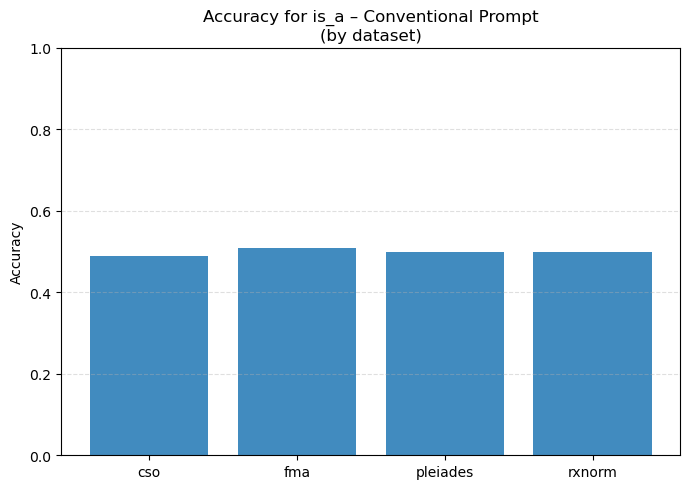

In [136]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict


df = results.query('family == "isa" and prompt == "Conventional Prompt"')



import re

def extract_dataset_name(path):
    m = re.match(r"([a-zA-Z0-9]+)", Path(path).stem)
    return m.group(1).lower() if m else Path(path).stem

if 'dataset' not in df.columns and 'prompt' in results.columns:
    new_records = []
    for model_dir in Path("responses").glob("*"):
        model = model_dir.name
        for fam_dir in model_dir.glob("*"):
            fam = _normalise_name(fam_dir.name)
            for prompt_dir in fam_dir.glob("*"):
                prompt = prompt_dir.name
                for fp in prompt_dir.glob("*.csv"):
                    dataset = extract_dataset_name(fp.name)
                    # rest as before...
                    try:
                        ddf = pd.read_csv(fp)
                        ans_col = _pick_answer_col(ddf)
                        ddf = ddf[["id", ans_col]].rename(columns={ans_col: "pred"})
                        ddf = ddf[ddf.id.isin(gt[fam])]
                        ddf["truth"] = ddf["id"].map(gt[fam])
                        ddf["correct"] = ddf.apply(
                            lambda r: str(r.pred).strip().lower().startswith(
                                      r.truth.strip().lower()[0]), axis=1)
                        acc = ddf["correct"].mean()
                        new_records.append(dict(model=model, family=fam,
                                                prompt=prompt, n=len(ddf), acc=acc,
                                                dataset=dataset))
                    except Exception as e:
                        continue
    df = pd.DataFrame(new_records).query('family == "isa" and prompt == "Conventional Prompt"')



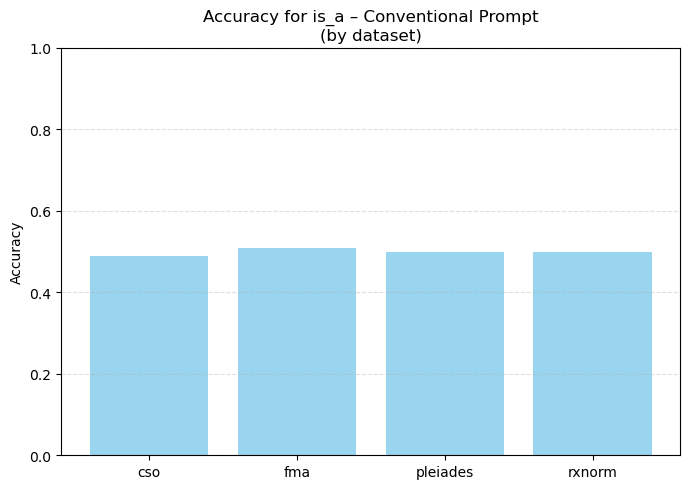

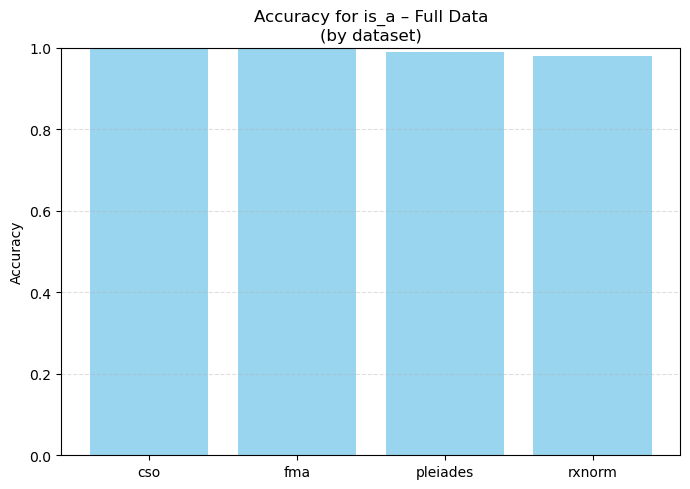

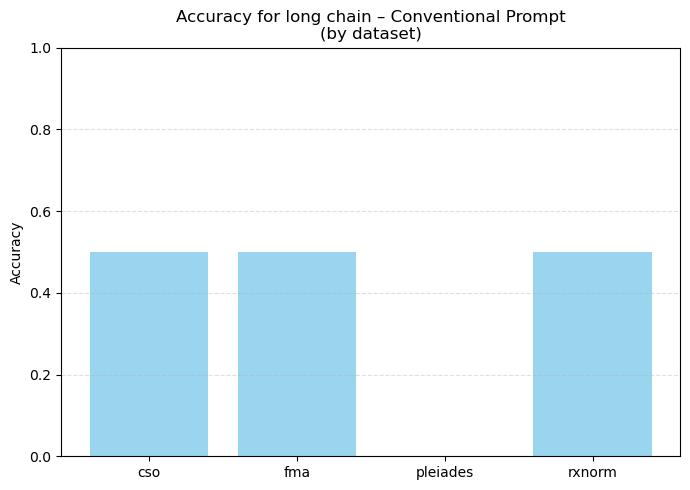

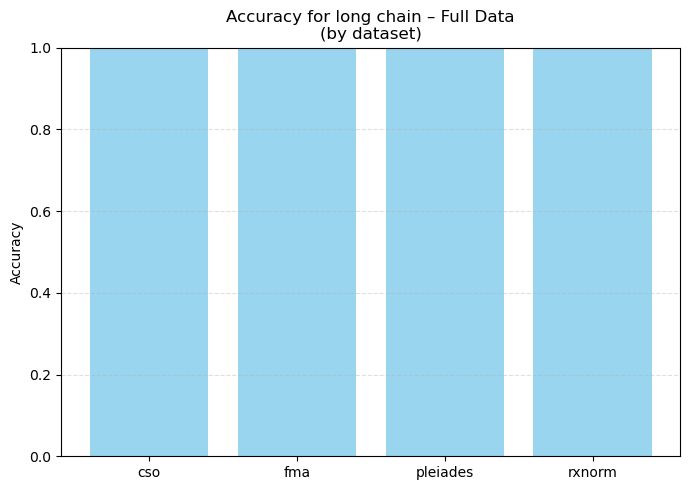

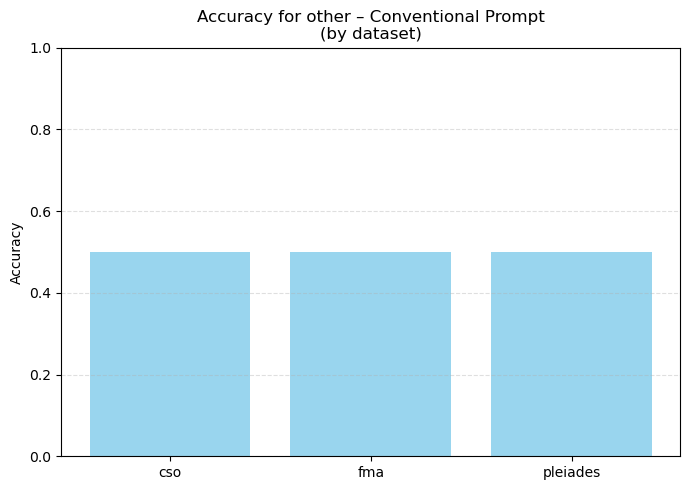

In [138]:
import matplotlib.pyplot as plt

DATASET_ORDER = ["cso", "fma", "pleiades", "rxnorm"]

plot_specs = [
    ("isa", "Conventional Prompt", "is_a – Conventional Prompt"),
    ("isa", "Full Data", "is_a – Full Data"),
    ("isa_long", "Conventional Prompt", "long chain – Conventional Prompt"),
    ("isa_long", "Full Data", "long chain – Full Data"),
    ("other", "Conventional Prompt", "other – Conventional Prompt"),
]

for family, prompt, title in plot_specs:
    df_sub = results.query('family == @family and prompt == @prompt')
    if df_sub.empty:
        print(f"No data for: {title}")
        continue

    if "dataset" in df_sub.columns:
        dset_acc = df_sub.set_index("dataset")["acc"].reindex(DATASET_ORDER)
        accs = dset_acc.values
    else:
        accs = df_sub["acc"].values
        accs = list(accs) + [float('nan')] * (4 - len(accs))

    labels = ["cso", "fma", "pleiades", "rxnorm"]
    plt.figure(figsize=(7, 5))
    plt.bar(labels, accs, color="skyblue", alpha=0.85)
    plt.ylim(0, 1)
    plt.ylabel("Accuracy")
    plt.title(f"Accuracy for {title}\n(by dataset)")
    plt.grid(axis="y", ls="--", alpha=.4)
    plt.tight_layout()
    plt.show()


Overall Accuracy for gpt4o_long_chain_answers: 50.0%


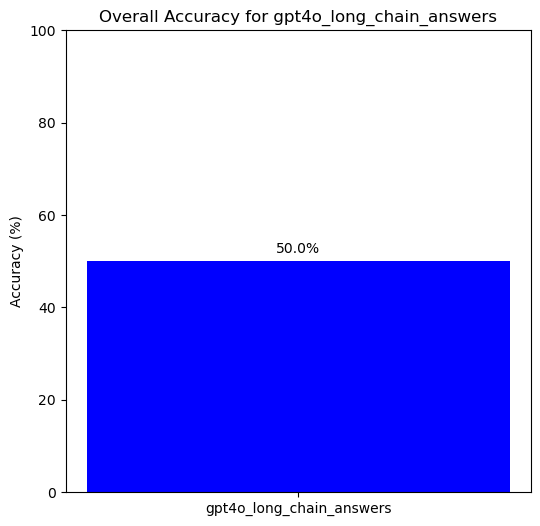

np.float64(50.04985044865404)